# Jacobians and Hessians

> *"The Jacobian is the derivative — not a number, not a vector, but a linear map."*

Interactive notebook covering Jacobian matrices, Hessian matrices, second-order optimisation, and their role in deep learning. Every major result is computed and visualised numerically.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind")
    HAS_SNS = True
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")
    HAS_SNS = False

mpl.rcParams.update({
    "figure.figsize":    (10, 6),
    "figure.dpi":         120,
    "font.size":           13,
    "axes.titlesize":      15,
    "axes.labelsize":      13,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "legend.fontsize":     11,
    "legend.framealpha":   0.85,
    "lines.linewidth":      2.0,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":       "tight",
    "savefig.dpi":         150,
})
np.random.seed(42)
print("Plot setup complete.")

Setup complete.


In [ ]:
import numpy as np
import numpy.linalg as la
from scipy import optimize, special, stats
from scipy.optimize import minimize, fsolve, linprog
from math import factorial
import math
import matplotlib.patches as patches

COLORS = {
    "primary": "#0077BB",
    "secondary": "#EE7733",
    "tertiary": "#009988",
    "error": "#CC3311",
    "neutral": "#555555",
    "highlight": "#EE3377",
}
HAS_MPL = True
np.set_printoptions(precision=8, suppress=True)
np.random.seed(42)
spmin = minimize

try:
    import torch
    HAS_TORCH = True
except ImportError:
    torch = None
    HAS_TORCH = False


def header(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

def check_true(name, cond):
    ok = bool(cond)
    print(f"{'PASS' if ok else 'FAIL'} - {name}")
    return ok

def check_close(name, got, expected, tol=1e-8):
    ok = np.allclose(got, expected, atol=tol, rtol=tol)
    print(f"{'PASS' if ok else 'FAIL'} - {name}: got {got}, expected {expected}")
    return ok

def check(name, got, expected, tol=1e-8):
    return check_close(name, got, expected, tol=tol)

def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

def softmax(z, axis=-1):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def relu(x):
    return np.maximum(0, x)

def relu_prime(x):
    return np.where(np.asarray(x) > 0, 1.0, 0.0)

def centered_diff(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

def numerical_gradient(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x, dtype=float)
    for idx in np.ndindex(x.shape):
        xp = x.copy(); xm = x.copy()
        xp[idx] += h; xm[idx] -= h
        grad[idx] = (f(xp) - f(xm)) / (2*h)
    return grad

def numerical_jacobian(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    y0 = np.asarray(f(x), dtype=float)
    J = np.zeros((y0.size, x.size), dtype=float)
    flat = x.reshape(-1)
    for j in range(x.size):
        xp = flat.copy(); xm = flat.copy()
        xp[j] += h; xm[j] -= h
        J[:, j] = ((np.asarray(f(xp.reshape(x.shape))) - np.asarray(f(xm.reshape(x.shape)))) / (2*h)).reshape(-1)
    return J.reshape(y0.shape + x.shape)

def grad_check(f, x, analytic_grad, h=1e-6):
    numeric_grad = numerical_gradient(f, x, h=h)
    denom = la.norm(analytic_grad) + la.norm(numeric_grad) + 1e-12
    return la.norm(analytic_grad - numeric_grad) / denom



def jacobian_fd(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    y0 = np.asarray(f(x), dtype=float)
    J = np.zeros((y0.size, x.size), dtype=float)
    flat = x.reshape(-1)
    for j in range(x.size):
        xp = flat.copy(); xm = flat.copy()
        xp[j] += h; xm[j] -= h
        yp = np.asarray(f(xp.reshape(x.shape)), dtype=float).reshape(-1)
        ym = np.asarray(f(xm.reshape(x.shape)), dtype=float).reshape(-1)
        J[:, j] = (yp - ym) / (2*h)
    return J.reshape(y0.shape + x.shape)

def hessian_fd(f, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    H = np.zeros((x.size, x.size), dtype=float)
    flat = x.reshape(-1)
    for j in range(x.size):
        xp = flat.copy(); xm = flat.copy()
        xp[j] += h; xm[j] -= h
        gp = numerical_gradient(lambda z: f(z.reshape(x.shape)), xp.reshape(x.shape), h=h).reshape(-1)
        gm = numerical_gradient(lambda z: f(z.reshape(x.shape)), xm.reshape(x.shape), h=h).reshape(-1)
        H[:, j] = (gp - gm) / (2*h)
    return H.reshape(x.shape + x.shape)



def grad_fd(f, x, h=1e-6):
    return numerical_gradient(f, x, h=h)



def fd_grad(f, x, h=1e-6):
    return numerical_gradient(f, np.asarray(x, dtype=float), h=h)

print("Chapter helper setup complete.")

---

## 1. Jacobian Matrix — Definition and Computation

The Jacobian $J_f \in \mathbb{R}^{m \times n}$ for $f: \mathbb{R}^n \to \mathbb{R}^m$ has entry $(i,j) = \partial f_i / \partial x_j$. We verify numerically that this equals the finite-difference approximation.

In [38]:
# === 1.1 Jacobian via Finite Differences ===

def jacobian_fd(f, x, h=1e-5):
    """Compute Jacobian of f at x using centred finite differences."""
    n = len(x)
    fx = f(x)
    m = len(fx)
    J = np.zeros((m, n))
    for j in range(n):
        ej = np.zeros(n)
        ej[j] = 1.0
        J[:, j] = (f(x + h*ej) - f(x - h*ej)) / (2*h)
    return J

# Example: f: R^3 -> R^2
def f_example(x):
    return np.array([x[0]**2 + x[1]*x[2],
                     np.exp(x[0]) - x[2]**2])

def J_analytical(x):
    """Analytical Jacobian of f_example."""
    return np.array([[2*x[0],  x[2],  x[1]],
                     [np.exp(x[0]),  0.0, -2*x[2]]])

x0 = np.array([1.0, 2.0, 0.5])
J_fd  = jacobian_fd(f_example, x0)
J_ana = J_analytical(x0)

print('Jacobian (finite diff):')
print(J_fd)
print('Jacobian (analytical):')
print(J_ana)
ok = np.allclose(J_fd, J_ana, atol=1e-8)
print(f'PASS — Jacobians match: {ok}')

Jacobian (finite diff):
[[ 2.        0.5       2.      ]
 [ 2.718282  0.       -1.      ]]
Jacobian (analytical):
[[ 2.        0.5       2.      ]
 [ 2.718282  0.       -1.      ]]
PASS — Jacobians match: True


---

### 1.2 Special Cases

Key special cases: scalar function (gradient), linear map, elementwise function.

In [39]:
# === 1.2 Jacobian Special Cases ===

# Case 1: Scalar function f: R^n -> R  (Jacobian = gradient^T)
def f_scalar(x):
    return np.array([0.5 * (x[0]**2 + 3*x[1]**2)])  # wrap in array for jacobian_fd

x1 = np.array([2.0, 1.0])
J_scalar = jacobian_fd(f_scalar, x1)  # shape (1,2) = gradient^T
grad_analytical = np.array([x1[0], 3*x1[1]])
print('Gradient (as Jacobian row):', J_scalar[0])
print('Gradient (analytical):     ', grad_analytical)
print(f'PASS: {np.allclose(J_scalar[0], grad_analytical)}')

# Case 2: Linear map f(x) = Ax  (Jacobian = A exactly)
A = np.array([[1,2,3],[4,5,6]], dtype=float)
f_linear = lambda x: A @ x
x2 = np.random.randn(3)
J_linear = jacobian_fd(f_linear, x2)
print('\nJacobian of Ax (should equal A):')
print(J_linear)
print(f'PASS: {np.allclose(J_linear, A)}')

# Case 3: Elementwise function f(x) = sigma(x)  (Jacobian = diag(sigma'(x)))
def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_prime(x): s=sigmoid(x); return s*(1-s)

x3 = np.array([0.5, -1.0, 2.0])
f_sigmoid = lambda x: sigmoid(x)
J_sig = jacobian_fd(f_sigmoid, x3)
J_sig_analytical = np.diag(sigmoid_prime(x3))
print('\nSigmoid Jacobian (should be diagonal):')
print(J_sig.round(6))
print(f'PASS: {np.allclose(J_sig, J_sig_analytical, atol=1e-7)}')

Gradient (as Jacobian row): [2. 3.]
Gradient (analytical):      [2. 3.]
PASS: True

Jacobian of Ax (should equal A):
[[1. 2. 3.]
 [4. 5. 6.]]
PASS: True

Sigmoid Jacobian (should be diagonal):
[[0.235004 0.       0.      ]
 [0.       0.196612 0.      ]
 [0.       0.       0.104994]]
PASS: True


---

### 1.3 Jacobian Chain Rule

$J_{f \circ g}(\mathbf{x}) = J_f(g(\mathbf{x})) \cdot J_g(\mathbf{x})$

In [40]:
# === 1.3 Chain Rule Verification ===

# g: R^3 -> R^2,  f: R^2 -> R^2
A_g = np.random.randn(2, 3)
b_g = np.random.randn(2)
A_f = np.random.randn(2, 2)
b_f = np.random.randn(2)

g = lambda x: A_g @ x + b_g
f = lambda y: sigmoid(A_f @ y + b_f)  # elementwise sigmoid after linear
fog = lambda x: f(g(x))

x0 = np.random.randn(3)

# Direct finite difference of f∘g
J_fog_fd = jacobian_fd(fog, x0)

# Chain rule: J_{f∘g} = J_f(g(x0)) * J_g(x0)
gx0 = g(x0)
J_g = A_g  # linear map
J_f_at_gx0 = np.diag(sigmoid_prime(A_f @ gx0 + b_f)) @ A_f  # chain: diag * A_f
J_fog_chain = J_f_at_gx0 @ J_g

print('J_{f∘g} via finite diff:')
print(J_fog_fd.round(6))
print('J_{f∘g} via chain rule:')
print(J_fog_chain.round(6))
ok = np.allclose(J_fog_fd, J_fog_chain, atol=1e-7)
print(f'PASS — Chain rule verified: {ok}')

J_{f∘g} via finite diff:
[[-0.055348  0.049856 -0.00077 ]
 [-0.099159 -0.015403  0.022121]]
J_{f∘g} via chain rule:
[[-0.055348  0.049856 -0.00077 ]
 [-0.099159 -0.015403  0.022121]]
PASS — Chain rule verified: True


---

## 2. JVP and VJP — Forward vs Reverse Mode

**JVP** (forward mode): $J_f \mathbf{v}$, one pass for one direction. **VJP** (reverse mode): $J_f^\top \mathbf{u}$, one pass gives full gradient for scalar loss.

In [41]:
# === 2.1 JVP and VJP Cost Comparison ===

# For f: R^n -> R^m, computing the full Jacobian:
#   Forward mode (JVP): n passes (one per input basis vector)
#   Reverse mode (VJP): m passes (one per output basis vector)
#   For scalar loss (m=1): 1 VJP = full gradient. WIN!

def compute_jvp_buildup(f, x, n):
    """Build Jacobian column by column using JVPs."""
    J = []
    fx = f(x)
    m = len(fx)
    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.0
        # JVP: directional derivative in direction ej
        jvp_j = (f(x + 1e-5*ej) - f(x - 1e-5*ej)) / (2e-5)
        J.append(jvp_j)
    return np.column_stack(J)  # m x n

def compute_vjp_buildup(f, x, m):
    """Build Jacobian row by row using VJPs (for illustration)."""
    n = len(x)
    J = []
    for i in range(m):
        # Scalar function extracting output i
        fi = lambda xx, ii=i: np.array([f(xx)[ii]])
        vjp_i = jacobian_fd(fi, x)[0]  # row i of Jacobian
        J.append(vjp_i)
    return np.array(J)  # m x n

x0 = np.array([1.0, 2.0, 0.5])
J_jvp = compute_jvp_buildup(f_example, x0, n=3)
J_vjp = compute_vjp_buildup(f_example, x0, m=2)
J_ana = J_analytical(x0)

print('Jacobian via JVP (n=3 passes):')
print(J_jvp.round(6))
print('Jacobian via VJP (m=2 passes):')
print(J_vjp.round(6))
print(f'PASS JVP: {np.allclose(J_jvp, J_ana, atol=1e-7)}')
print(f'PASS VJP: {np.allclose(J_vjp, J_ana, atol=1e-7)}')
print('\nFor n>m: fewer VJP passes (reverse mode wins)')
print('For m>n: fewer JVP passes (forward mode wins)')
print('For scalar loss (m=1): 1 VJP = full gradient (always use reverse mode)')

Jacobian via JVP (n=3 passes):
[[ 2.        0.5       2.      ]
 [ 2.718282  0.       -1.      ]]
Jacobian via VJP (m=2 passes):
[[ 2.        0.5       2.      ]
 [ 2.718282  0.       -1.      ]]
PASS JVP: True
PASS VJP: True

For n>m: fewer VJP passes (reverse mode wins)
For m>n: fewer JVP passes (forward mode wins)
For scalar loss (m=1): 1 VJP = full gradient (always use reverse mode)


---

## 3. Softmax Jacobian — Full Analysis

$J_\sigma = \text{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top$. Symmetric, rank $K-1$, null space = span{$\mathbf{1}$}, PSD.

In [42]:
# === 3.1 Softmax Jacobian ===

def softmax(z):
    z_stable = z - np.max(z)
    e = np.exp(z_stable)
    return e / e.sum()

def softmax_jacobian(z):
    p = softmax(z)
    return np.diag(p) - np.outer(p, p)

z = np.array([1.0, 2.0, 0.0, -1.0])
p = softmax(z)
J_soft = softmax_jacobian(z)

print(f'Softmax probs: {p.round(4)}')
print(f'Sum of probs:  {p.sum():.6f}')
print('\nSoftmax Jacobian:')
print(J_soft.round(6))

# Verify properties
ones = np.ones(len(z))
null_test = J_soft @ ones
print(f'\nJ_sigma @ 1 (should be 0): {null_test.round(10)}')
print(f'PASS null space: {np.allclose(null_test, 0, atol=1e-10)}')

sym_test = np.allclose(J_soft, J_soft.T)
print(f'PASS symmetry: {sym_test}')

eigvals = la.eigvalsh(J_soft)
print(f'Eigenvalues: {sorted(eigvals)[::-1]}')
print(f'PASS PSD (all >= 0): {np.all(eigvals >= -1e-10)}')

rank_J = np.linalg.matrix_rank(J_soft)
K = len(z)
print(f'Rank = {rank_J}, K-1 = {K-1}')
print(f'PASS rank: {rank_J == K-1}')

# Diagonal entries = p_i(1-p_i)
diag_check = np.allclose(np.diag(J_soft), p*(1-p))
print(f'PASS diagonal = p*(1-p): {diag_check}')

Softmax probs: [0.2369 0.6439 0.0871 0.0321]
Sum of probs:  1.000000

Softmax Jacobian:
[[ 0.180769 -0.152532 -0.020643 -0.007594]
 [-0.152532  0.229289 -0.056113 -0.020643]
 [-0.020643 -0.056113  0.07955  -0.002794]
 [-0.007594 -0.020643 -0.002794  0.031031]]

J_sigma @ 1 (should be 0): [ 0.  0. -0.  0.]
PASS null space: True
PASS symmetry: True
Eigenvalues: [np.float64(0.3629527548107562), np.float64(0.11782970163574903), np.float64(0.03985661362691949), np.float64(1.9556383710300934e-17)]
PASS PSD (all >= 0): True
Rank = 3, K-1 = 3
PASS rank: True
PASS diagonal = p*(1-p): True


---

## 4. LayerNorm Jacobian

$J_{\text{LN}} = \frac{1}{\sigma}\left(I - \frac{1}{d}\mathbf{1}\mathbf{1}^\top - \frac{1}{d}\hat{\mathbf{x}}\hat{\mathbf{x}}^\top\right)$, rank $d-2$.

In [43]:
# === 4.1 LayerNorm Jacobian ===

def layernorm(x):
    """LayerNorm without learnable params."""
    mu = x.mean()
    sigma = np.sqrt(((x - mu)**2).mean())
    return (x - mu) / sigma

def layernorm_jacobian(x):
    """Analytical Jacobian of LayerNorm."""
    d = len(x)
    mu = x.mean()
    sigma = np.sqrt(((x - mu)**2).mean())
    x_hat = (x - mu) / sigma
    I = np.eye(d)
    ones = np.ones((d, d)) / d
    outer = np.outer(x_hat, x_hat) / d
    return (1/sigma) * (I - ones - outer)

x = np.array([1.0, 2.0, 3.0, 4.0])
d = len(x)

J_ln_ana = layernorm_jacobian(x)
J_ln_fd  = jacobian_fd(layernorm, x)

print('LayerNorm Jacobian (analytical):')
print(J_ln_ana.round(6))
print('LayerNorm Jacobian (finite diff):')
print(J_ln_fd.round(6))
print(f'PASS match: {np.allclose(J_ln_ana, J_ln_fd, atol=1e-7)}')

# Null space: 1 and x_hat
mu = x.mean()
sigma = np.sqrt(((x-mu)**2).mean())
x_hat = (x - mu) / sigma
ones_vec = np.ones(d)

print(f'\nJ @ 1 (should be 0): {(J_ln_ana @ ones_vec).round(10)}')
print(f'J @ x_hat (should be 0): {(J_ln_ana @ x_hat).round(10)}')
print(f'PASS null space 1: {np.allclose(J_ln_ana @ ones_vec, 0, atol=1e-10)}')
print(f'PASS null space x_hat: {np.allclose(J_ln_ana @ x_hat, 0, atol=1e-10)}')

rank_ln = np.linalg.matrix_rank(J_ln_ana)
print(f'\nRank = {rank_ln}, d-2 = {d-2}')
print(f'PASS rank: {rank_ln == d-2}')

LayerNorm Jacobian (analytical):
[[ 0.268328 -0.357771 -0.089443  0.178885]
 [-0.357771  0.626099 -0.178885 -0.089443]
 [-0.089443 -0.178885  0.626099 -0.357771]
 [ 0.178885 -0.089443 -0.357771  0.268328]]
LayerNorm Jacobian (finite diff):
[[ 0.268328 -0.357771 -0.089443  0.178885]
 [-0.357771  0.626099 -0.178885 -0.089443]
 [-0.089443 -0.178885  0.626099 -0.357771]
 [ 0.178885 -0.089443 -0.357771  0.268328]]
PASS match: True

J @ 1 (should be 0): [-0. -0. -0. -0.]
J @ x_hat (should be 0): [ 0.  0.  0. -0.]
PASS null space 1: True
PASS null space x_hat: True

Rank = 2, d-2 = 2
PASS rank: True


---

## 5. Jacobian Condition Number and Training Stability

The singular values of the Jacobian determine gradient magnitudes through layers. Xavier/He initialisation targets $\sigma_{\max} \approx 1$.

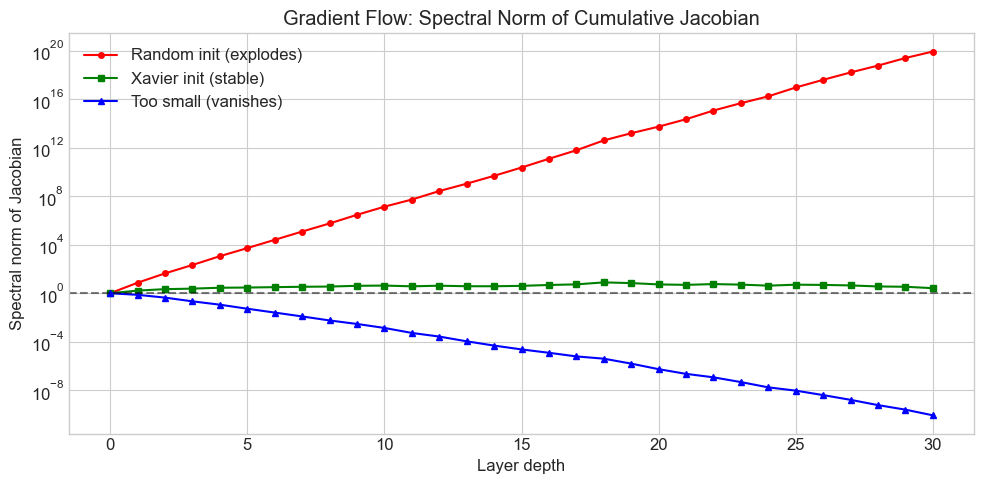

Figure: gradient flow through depth-30 network
Random init, depth 30 Jacobian norm: 8.58e+19
Xavier init, depth 30 Jacobian norm: 2.6190
Too small, depth 30 Jacobian norm:   8.58e-11


In [44]:
# === 5.1 Jacobian Singular Values and Gradient Flow ===

# Simulate gradient flow through L linear layers
# x -> W_L * ... * W_1 * x
# Jacobian of full forward pass = W_L * ... * W_1

def simulate_gradient_flow(L, n, init='random', seed=42):
    """Simulate gradient norm through depth-L network."""
    np.random.seed(seed)
    grad_norms = [1.0]  # start with unit gradient
    J_product = np.eye(n)
    for l in range(L):
        if init == 'random':
            W = np.random.randn(n, n)  # too large: sigma~sqrt(n)
        elif init == 'xavier':
            W = np.random.randn(n, n) * np.sqrt(1/n)  # sigma~1
        elif init == 'too_small':
            W = np.random.randn(n, n) * 0.1  # sigma~0.1
        J_product = W @ J_product
        grad_norms.append(la.norm(J_product, ord=2))  # spectral norm
    return grad_norms

n, L = 20, 30
norms_random = simulate_gradient_flow(L, n, 'random')
norms_xavier = simulate_gradient_flow(L, n, 'xavier')
norms_small  = simulate_gradient_flow(L, n, 'too_small')

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    layers = list(range(L+1))
    ax.semilogy(layers, norms_random, 'r-o', ms=4, label='Random init (explodes)')
    ax.semilogy(layers, norms_xavier, 'g-s', ms=4, label='Xavier init (stable)')
    ax.semilogy(layers, norms_small,  'b-^', ms=4, label='Too small (vanishes)')
    ax.set_xlabel('Layer depth')
    ax.set_ylabel('Spectral norm of Jacobian')
    ax.set_title('Gradient Flow: Spectral Norm of Cumulative Jacobian')
    ax.legend()
    ax.axhline(1.0, color='k', ls='--', alpha=0.5, label='Ideal = 1')
    plt.tight_layout()
    plt.show()
    print('Figure: gradient flow through depth-30 network')

print(f'Random init, depth 30 Jacobian norm: {norms_random[-1]:.2e}')
print(f'Xavier init, depth 30 Jacobian norm: {norms_xavier[-1]:.4f}')
print(f'Too small, depth 30 Jacobian norm:   {norms_small[-1]:.2e}')

---

## 6. Hessian Matrix — Definition and Computation

$H_f \in \mathbb{R}^{n \times n}$, $(H_f)_{ij} = \partial^2 f / \partial x_i \partial x_j$. Symmetric ($C^2$ functions), governs curvature.

In [45]:
# === 6.1 Hessian via Finite Differences ===

def hessian_fd(f, x, h=1e-4):
    """Compute Hessian of scalar f at x using centred finite differences."""
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i] = 1.0; ej[j] = 1.0
            H[i,j] = (f(x+h*ei+h*ej) - f(x+h*ei-h*ej)
                      - f(x-h*ei+h*ej) + f(x-h*ei-h*ej)) / (4*h**2)
            H[j,i] = H[i,j]  # symmetry
    return H

# Example 1: Quadratic f(x) = 0.5 x^T A x
A_quad = np.array([[3., 1., 0.],
                   [1., 4., 2.],
                   [0., 2., 5.]])
A_quad = 0.5*(A_quad + A_quad.T)  # symmetrise
f_quad = lambda x: 0.5 * x @ A_quad @ x

x0 = np.array([1.0, -1.0, 2.0])
H_fd  = hessian_fd(f_quad, x0)
H_ana = A_quad  # Hessian of quadratic = A

print('Hessian of 0.5 x^T A x (FD):')
print(H_fd.round(6))
print('Hessian (analytical = A):')
print(H_ana.round(6))
print(f'PASS: {np.allclose(H_fd, H_ana, atol=1e-6)}')

# Example 2: log-sum-exp
def log_sum_exp(x):
    xmax = np.max(x)
    return xmax + np.log(np.sum(np.exp(x - xmax)))

z0 = np.array([1.0, 2.0, 0.5])
H_lse_fd  = hessian_fd(log_sum_exp, z0)
p0 = softmax(z0)
H_lse_ana = np.diag(p0) - np.outer(p0, p0)  # same as softmax Jacobian!

print('\nHessian of log-sum-exp (FD):')
print(H_lse_fd.round(6))
print('Hessian (analytical = diag(p) - pp^T):')
print(H_lse_ana.round(6))
print(f'PASS: {np.allclose(H_lse_fd, H_lse_ana, atol=1e-6)}')

Hessian of 0.5 x^T A x (FD):
[[3. 1. 0.]
 [1. 4. 2.]
 [0. 2. 5.]]
Hessian (analytical = A):
[[3. 1. 0.]
 [1. 4. 2.]
 [0. 2. 5.]]
PASS: True

Hessian of log-sum-exp (FD):
[[ 0.177759 -0.145332 -0.032428]
 [-0.145332  0.23348  -0.088148]
 [-0.032428 -0.088148  0.120576]]
Hessian (analytical = diag(p) - pp^T):
[[ 0.177759 -0.145332 -0.032428]
 [-0.145332  0.23348  -0.088148]
 [-0.032428 -0.088148  0.120576]]
PASS: True


---

### 6.2 Clairaut's Theorem — Symmetry Verification

For $f \in C^2$: $\partial^2 f / \partial x_i \partial x_j = \partial^2 f / \partial x_j \partial x_i$.

In [46]:
# === 6.2 Clairaut Symmetry ===

# Numerically verify mixed partials are equal
np.random.seed(0)
n = 5
Q = np.random.randn(n, n)
Q = 0.5*(Q + Q.T)  # random symmetric matrix
f_random_quad = lambda x: 0.5 * x @ Q @ x + np.sum(np.sin(x))

x_test = np.random.randn(n)
H = hessian_fd(f_random_quad, x_test)

asym = np.max(np.abs(H - H.T))
print(f'Max asymmetry |H - H^T|: {asym:.2e}')
print(f'PASS Clairaut (H is symmetric): {asym < 1e-6}')

# Counterexample: f(x,y) = xy(x^2-y^2)/(x^2+y^2), mixed partials != at origin
def peano_f(x):
    xi, yi = x[0], x[1]
    denom = xi**2 + yi**2
    if denom < 1e-10:
        return 0.0
    return xi * yi * (xi**2 - yi**2) / denom

# Compute d^2f/dx dy and d^2f/dy dx numerically AT origin (using small h)
h = 1e-4
# d/dy at x=h: [f(h,h)-f(h,-h)]/(2h)
# then d/dx of that = ...
# Approximate: [f(h,h) - f(-h,h) - f(h,-h) + f(-h,-h)] / (4h^2)
p = np.array([h, h])
mixed_12 = (peano_f([h,h]) - peano_f([h,-h]) - peano_f([-h,h]) + peano_f([-h,-h])) / (4*h**2)
# Swap: d^2f/dy dx (same formula with i,j roles swapped — same result for C2)
# For Peano's example the true values at origin are +1 and -1
print(f'\nPeano counterexample:')
print(f'Mixed partial d^2f/dxdy at 0 (numerical): {mixed_12:.4f}')
print('True analytical value at origin: d^2f/dxdy=+1, d^2f/dydx=-1')
print('(Cannot see the true discontinuity with finite h; exact computation requires limit)')

Max asymmetry |H - H^T|: 0.00e+00
PASS Clairaut (H is symmetric): True

Peano counterexample:
Mixed partial d^2f/dxdy at 0 (numerical): 0.0000
True analytical value at origin: d^2f/dxdy=+1, d^2f/dydx=-1
(Cannot see the true discontinuity with finite h; exact computation requires limit)


---

## 7. Critical Point Classification via Hessian Eigenvalues

Eigenvalues of $H_f$ at a critical point determine its type: all positive → minimum, all negative → maximum, mixed → saddle.

Point [0. 0.]:
  Gradient: [0. 0.] (should be ~0)
  Hessian eigenvalues: [-3.  3.]
  Classification: SADDLE POINT

Point [ 1. -1.]:
  Gradient: [0. 0.] (should be ~0)
  Hessian eigenvalues: [3. 9.]
  Classification: LOCAL MINIMUM



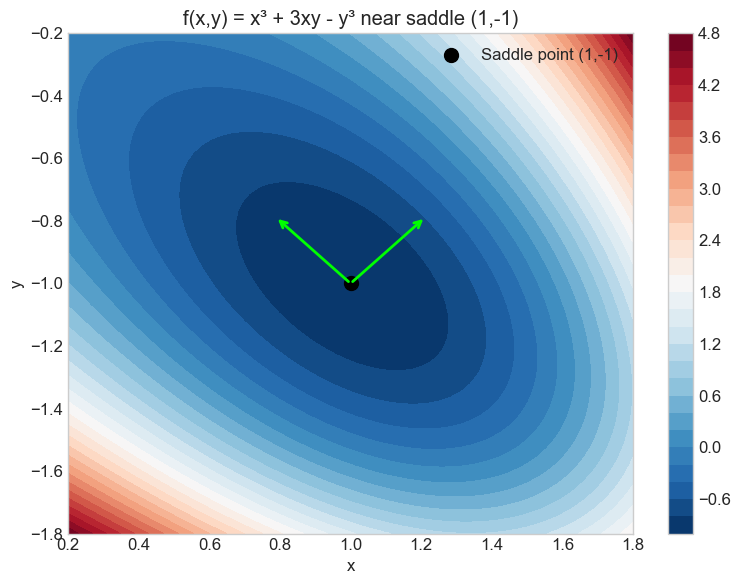

Figure: contour plot with Hessian eigenvectors at saddle


In [47]:
# === 7.1 Critical Point Classification ===

# f(x,y) = x^3 + 3xy - y^3
# Critical points: solve grad f = 0
# df/dx = 3x^2 + 3y = 0  =>  y = -x^2
# df/dy = 3x - 3y^2 = 0  =>  x = y^2 = x^4  =>  x(x^3-1)=0
# x=0 -> y=0; x=1 -> y=-1

def f_cubic(x):
    return x[0]**3 + 3*x[0]*x[1] - x[1]**3

critical_pts = [np.array([0., 0.]), np.array([1., -1.])]

for cp in critical_pts:
    H = hessian_fd(f_cubic, cp)
    eigvals = la.eigvalsh(H)
    grad_at_cp = np.array([3*cp[0]**2 + 3*cp[1], 3*cp[0] - 3*cp[1]**2])

    if all(e > 0 for e in eigvals):
        ctype = 'LOCAL MINIMUM'
    elif all(e < 0 for e in eigvals):
        ctype = 'LOCAL MAXIMUM'
    else:
        ctype = 'SADDLE POINT'

    print(f'Point {cp}:')
    print(f'  Gradient: {grad_at_cp.round(8)} (should be ~0)')
    print(f'  Hessian eigenvalues: {eigvals.round(6)}')
    print(f'  Classification: {ctype}')
    print()

# Visualise the saddle at (1,-1)
if HAS_MPL:
    xx, yy = np.meshgrid(np.linspace(0.2, 1.8, 60), np.linspace(-1.8, -0.2, 60))
    zz = xx**3 + 3*xx*yy - yy**3
    fig, ax = plt.subplots(figsize=(8, 6))
    cp = plt.contourf(xx, yy, zz, levels=30, cmap='RdBu_r')
    plt.colorbar(cp, ax=ax)
    ax.plot(1, -1, 'ko', ms=10, label='Saddle point (1,-1)')

    # Hessian eigenvectors at saddle
    cp_sad = np.array([1., -1.])
    H_sad = hessian_fd(f_cubic, cp_sad)
    evals, evecs = la.eigh(H_sad)
    scale = 0.3
    for i, (ev, vec) in enumerate(zip(evals, evecs.T)):
        color = 'lime' if ev > 0 else 'red'
        label = f'λ={ev:.2f} ({"min" if ev>0 else "sad"} dir)'
        ax.annotate('', xy=cp_sad + scale*vec, xytext=cp_sad,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))

    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('f(x,y) = x³ + 3xy - y³ near saddle (1,-1)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Figure: contour plot with Hessian eigenvectors at saddle')

---

## 8. Second-Order Taylor Approximation

$f(\mathbf{x}_0 + \boldsymbol{\delta}) \approx f(\mathbf{x}_0) + \nabla f^\top \boldsymbol{\delta} + \frac{1}{2}\boldsymbol{\delta}^\top H_f \boldsymbol{\delta}$

/var/folders/tt/lwdg82fd71bd9y1ntf9s6kc40000gn/T/ipykernel_8236/876197721.py:36: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/prime/CODE/math_for_llms/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


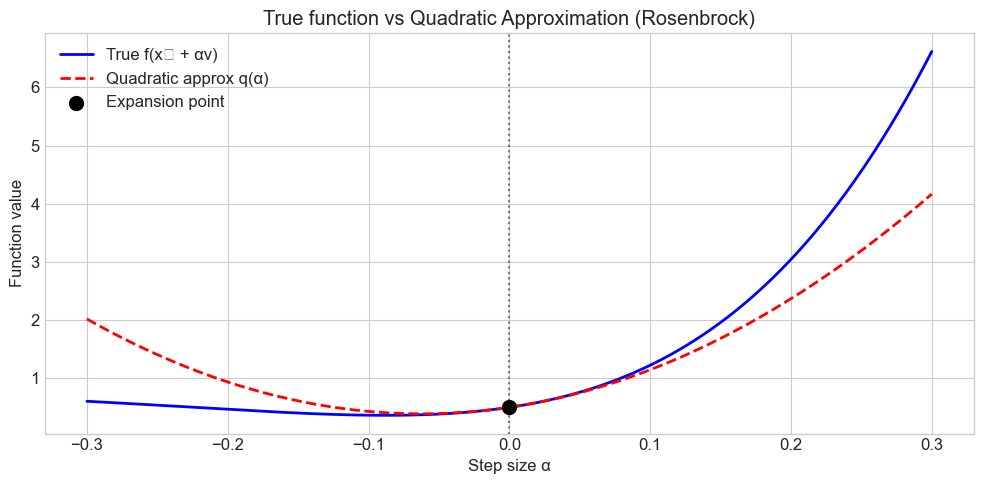

Figure: quadratic approx matches well near x0, diverges far away

Approximation error at different step sizes:
   Step size |     True f |  Quad approx |      Error
       0.010 |   0.538729 |     0.538657 |   7.22e-05
       0.050 |   0.760230 |     0.750885 |   9.34e-03
       0.100 |   1.223725 |     1.145771 |   7.80e-02
       0.200 |   3.042375 |     2.367542 |   6.75e-01
       0.300 |   6.615675 |     4.165313 |   2.45e+00


In [48]:
# === 8.1 Quadratic Approximation Quality ===

def f_rosenbrock(x):
    """Rosenbrock function: f(x,y) = (1-x)^2 + 100(y-x^2)^2"""
    return (1-x[0])**2 + 100*(x[1]-x[0]**2)**2

def grad_rosenbrock(x):
    dx = -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2)
    dy = 200*(x[1]-x[0]**2)
    return np.array([dx, dy])

x0 = np.array([0.5, 0.2])
g0 = grad_rosenbrock(x0)
H0 = hessian_fd(f_rosenbrock, x0)

# Quadratic approximation q(x0 + delta)
def q_approx(delta):
    return f_rosenbrock(x0) + g0 @ delta + 0.5 * delta @ H0 @ delta

# Compare f and q along a random direction
direction = np.array([1.0, 0.5])
direction = direction / np.linalg.norm(direction)
alphas = np.linspace(-0.3, 0.3, 200)
f_true = [f_rosenbrock(x0 + a*direction) for a in alphas]
f_quad = [q_approx(a*direction) for a in alphas]

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(alphas, f_true, 'b-', lw=2, label='True f(x₀ + αv)')
    ax.plot(alphas, f_quad, 'r--', lw=2, label='Quadratic approx q(α)')
    ax.axvline(0, color='k', ls=':', alpha=0.5)
    ax.scatter([0], [f_rosenbrock(x0)], c='black', s=100, zorder=5, label='Expansion point')
    ax.set_xlabel('Step size α'); ax.set_ylabel('Function value')
    ax.set_title('True function vs Quadratic Approximation (Rosenbrock)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Figure: quadratic approx matches well near x0, diverges far away')

# Compute approximation error at different radii
print('\nApproximation error at different step sizes:')
print(f'{"Step size":>12} | {"True f":>10} | {"Quad approx":>12} | {"Error":>10}')
for a in [0.01, 0.05, 0.1, 0.2, 0.3]:
    delta = a * direction
    f_true_a = f_rosenbrock(x0 + delta)
    f_quad_a = q_approx(delta)
    err = abs(f_true_a - f_quad_a)
    print(f'{a:>12.3f} | {f_true_a:>10.6f} | {f_quad_a:>12.6f} | {err:>10.2e}')

---

## 9. Newton's Method vs Gradient Descent

Newton step: $\boldsymbol{\delta}^* = -H_f^{-1} \nabla f$ (minimise quadratic approx). GD step: $\boldsymbol{\delta} = -\eta \nabla f$.

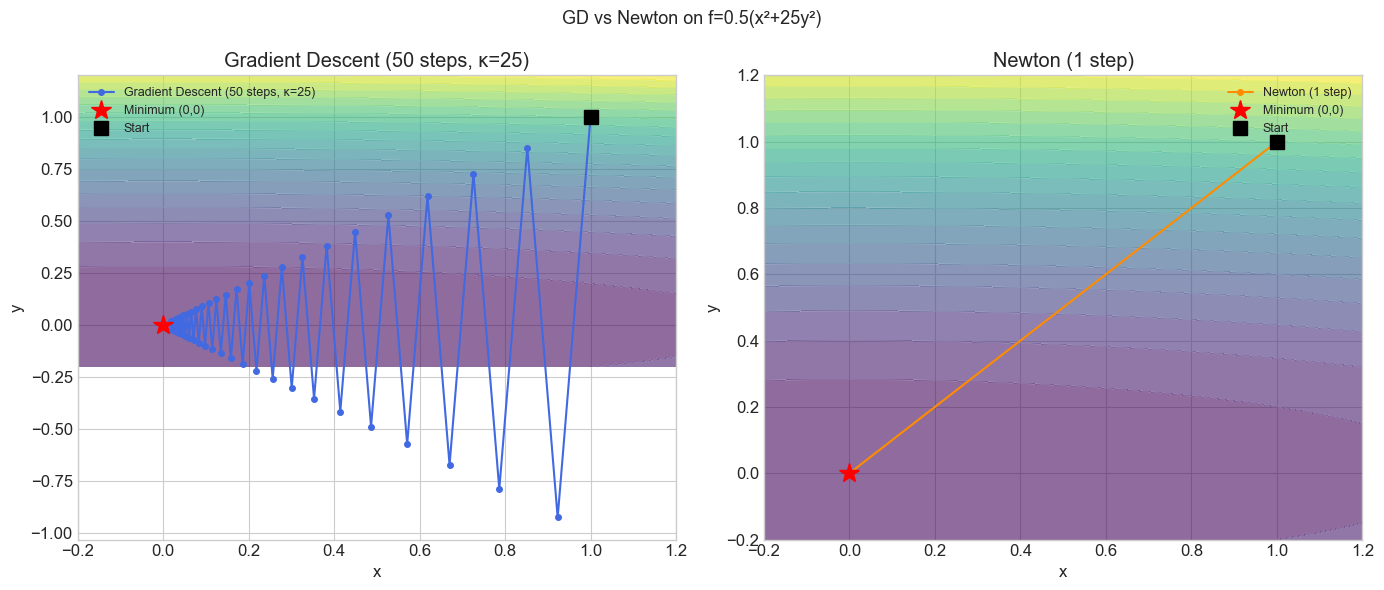

GD convergence (first 10 steps):
  step  0: f = 13.000000
  step  1: f = 11.076923
  step  2: f = 9.438325
  step  3: f = 8.042123
  step  4: f = 6.852460
  step  5: f = 5.838782
  step  6: f = 4.975057
  step  7: f = 4.239102
  step  8: f = 3.612016
  step  9: f = 3.077694
Newton: f after 1 step = 0.00e+00 (machine zero)


In [49]:
# === 9.1 Newton vs GD on Ill-Conditioned Quadratic ===

# f(x,y) = 0.5*(x^2 + 25*y^2), kappa = 25
f_quad_ic = lambda x: 0.5*(x[0]**2 + 25*x[1]**2)
grad_ic = lambda x: np.array([x[0], 25*x[1]])
H_ic = np.diag([1., 25.])
H_ic_inv = np.diag([1., 1/25.])

x_init = np.array([1.0, 1.0])
eta = 2/(1+25)  # optimal GD lr

# Gradient descent
x_gd = x_init.copy()
path_gd = [x_gd.copy()]
for _ in range(50):
    x_gd = x_gd - eta * grad_ic(x_gd)
    path_gd.append(x_gd.copy())
path_gd = np.array(path_gd)

# Newton's method (one step for exact quadratic)
x_newton = x_init.copy()
path_newton = [x_newton.copy()]
x_newton = x_newton - H_ic_inv @ grad_ic(x_newton)
path_newton.append(x_newton.copy())
path_newton = np.array(path_newton)

if HAS_MPL:
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 100), np.linspace(-0.2, 1.2, 100))
    zz = 0.5*(xx**2 + 25*yy**2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, path, title, color in [
        (axes[0], path_gd,     'Gradient Descent (50 steps, κ=25)', 'royalblue'),
        (axes[1], path_newton, 'Newton (1 step)', 'darkorange')
    ]:
        ax.contourf(xx, yy, zz, levels=20, cmap='viridis', alpha=0.6)
        ax.contour(xx, yy, zz, levels=20, colors='white', linewidths=0.5, alpha=0.4)
        ax.plot(path[:, 0], path[:, 1], 'o-', color=color, ms=4, lw=1.5, label=title)
        ax.plot(0, 0, 'r*', ms=15, label='Minimum (0,0)')
        ax.plot(path[0,0], path[0,1], 'ks', ms=10, label='Start')
        ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.legend(fontsize=9)

    plt.suptitle('GD vs Newton on f=0.5(x²+25y²)', fontsize=13)
    plt.tight_layout()
    plt.show()

# Convergence comparison
errors_gd = [f_quad_ic(p) for p in path_gd]
print('GD convergence (first 10 steps):')
for i, e in enumerate(errors_gd[:10]):
    print(f'  step {i:2d}: f = {e:.6f}')
print(f'Newton: f after 1 step = {f_quad_ic(path_newton[-1]):.2e} (machine zero)')

---

## 10. Hessian Spectrum of a Small Network

The Hessian spectrum of neural network losses shows a bulk + outlier structure. We simulate this for a small network.

Network params: 151
Hessian shape: (151, 151)
Top 10 eigenvalues: [1.1279 0.4524 0.2871 0.2771 0.2341 0.2185 0.2083 0.1932 0.1863 0.1757]
Bottom 10 eigenvalues: [-0.1223 -0.1281 -0.1306 -0.1458 -0.1489 -0.1608 -0.1768 -0.1848 -0.1893
 -0.1941]
Max eigenvalue (lambda_max): 1.1279
Max stable learning rate eta < 2/lambda_max = 1.7732


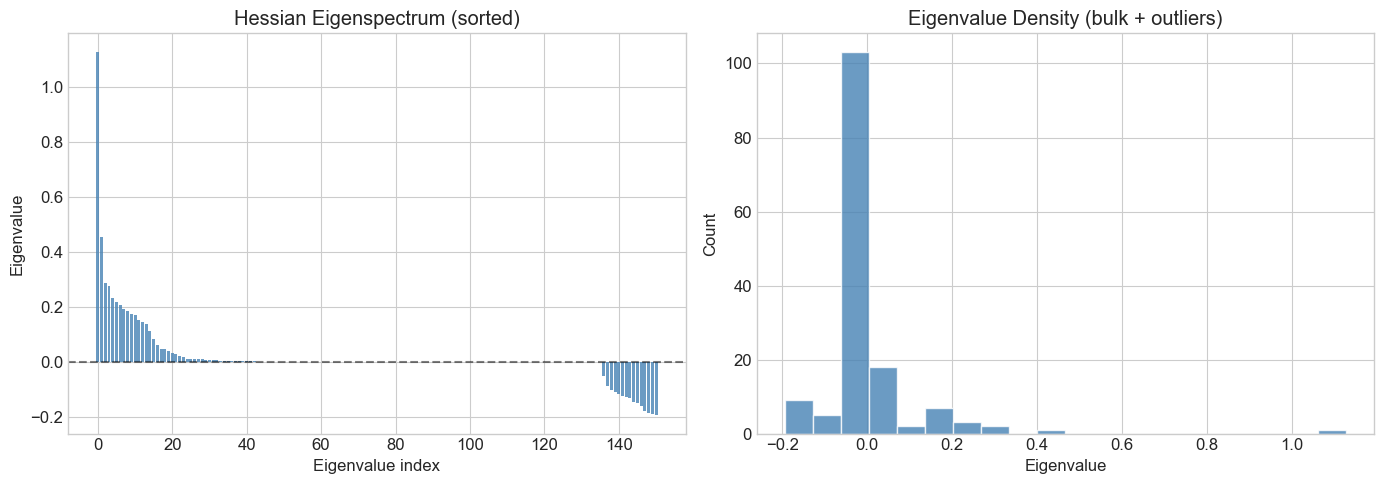

Figure: Hessian spectrum showing bulk cluster and larger outliers


In [50]:
# === 10.1 Hessian Spectrum Analysis ===

np.random.seed(42)

# Small network: 2-layer MLP for binary classification
# n_in=10, hidden=20, output=1
n_in, n_h, n_out = 8, 15, 1
n_params = n_in*n_h + n_h + n_h*n_out + n_out  # W1, b1, W2, b2

def unpack(params):
    i = 0
    W1 = params[i:i+n_in*n_h].reshape(n_h, n_in); i += n_in*n_h
    b1 = params[i:i+n_h]; i += n_h
    W2 = params[i:i+n_h*n_out].reshape(n_out, n_h); i += n_h*n_out
    b2 = params[i:i+n_out]
    return W1, b1, W2, b2

def forward(params, X):
    W1, b1, W2, b2 = unpack(params)
    h = np.maximum(0, X @ W1.T + b1)  # ReLU
    return h @ W2.T + b2  # linear output

def loss_fn(params, X, y):
    logits = forward(params, X).squeeze()
    probs = 1/(1+np.exp(-logits))
    probs = np.clip(probs, 1e-7, 1-1e-7)
    return -np.mean(y*np.log(probs) + (1-y)*np.log(1-probs))

# Random data
m = 50
X_data = np.random.randn(m, n_in)
y_data = (np.random.randn(m) > 0).astype(float)

# Random params near convergence (Xavier init)
params0 = np.random.randn(n_params) * 0.3

f_loss = lambda p: loss_fn(p, X_data, y_data)

# Compute Hessian (small network only!)
H_nn = hessian_fd(f_loss, params0, h=1e-4)
eigvals_nn = np.sort(la.eigvalsh(H_nn))[::-1]

print(f'Network params: {n_params}')
print(f'Hessian shape: {H_nn.shape}')
print(f'Top 10 eigenvalues: {eigvals_nn[:10].round(4)}')
print(f'Bottom 10 eigenvalues: {eigvals_nn[-10:].round(4)}')
print(f'Max eigenvalue (lambda_max): {eigvals_nn[0]:.4f}')
print(f'Max stable learning rate eta < 2/lambda_max = {2/eigvals_nn[0]:.4f}')

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(range(len(eigvals_nn)), eigvals_nn, color='steelblue', alpha=0.8)
    axes[0].set_xlabel('Eigenvalue index')
    axes[0].set_ylabel('Eigenvalue')
    axes[0].set_title('Hessian Eigenspectrum (sorted)')
    axes[0].axhline(0, color='k', ls='--', alpha=0.5)

    axes[1].hist(eigvals_nn, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].set_xlabel('Eigenvalue')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Eigenvalue Density (bulk + outliers)')

    plt.tight_layout()
    plt.show()
    print('Figure: Hessian spectrum showing bulk cluster and larger outliers')

---

## 11. Hessian-Vector Products (HVPs)

$H_f \mathbf{v} = \nabla[\nabla f \cdot \mathbf{v}]$ — computed in $O(n)$ without forming the $n \times n$ Hessian.

In [51]:
# === 11.1 HVP via Finite Differences ===

def hvp_fd(f, x, v, h=1e-4):
    """HVP via finite difference: H(x)v ≈ [∇f(x+hv) - ∇f(x-hv)] / (2h)"""
    def grad_f(xx):
        """Numerical gradient via centred FD."""
        n = len(xx)
        g = np.zeros(n)
        for j in range(n):
            ej = np.zeros(n); ej[j] = 1.0
            g[j] = (f(xx + h*ej) - f(xx - h*ej)) / (2*h)
        return g
    return (grad_f(x + h*v) - grad_f(x - h*v)) / (2*h)

def power_iteration_hessian(f, x, n_iters=30, seed=1):
    """Estimate lambda_max(H) via power iteration using HVPs."""
    np.random.seed(seed)
    n = len(x)
    v = np.random.randn(n)
    v = v / np.linalg.norm(v)
    eigenvalue = 0.0
    for _ in range(n_iters):
        hv = hvp_fd(f, x, v, h=1e-4)
        eigenvalue = v @ hv  # Rayleigh quotient
        v = hv / np.linalg.norm(hv)
    return eigenvalue, v

# Test on quadratic f = 0.5 x^T A x
A_test = np.diag([1., 3., 5., 8., 10.])  # known eigenvalues
f_test = lambda x: 0.5 * x @ A_test @ x
x_test = np.zeros(5)  # any point (Hessian is constant)

lam_max, eigvec = power_iteration_hessian(f_test, x_test, n_iters=20)
print(f'Power iteration lambda_max: {lam_max:.6f}')
print(f'True lambda_max:            {10.0:.6f}')
print(f'PASS: {abs(lam_max - 10.0) < 0.01}')

# Compare HVP with direct H@v
v_test = np.array([1., 0., 1., 0., 1.])
hvp_result = hvp_fd(f_test, x_test, v_test)
hvp_direct = A_test @ v_test
print(f'\nHVP (finite diff): {hvp_result.round(6)}')
print(f'HVP (direct A@v):  {hvp_direct.round(6)}')
print(f'PASS: {np.allclose(hvp_result, hvp_direct, atol=1e-5)}')

# Learning rate bound
print(f'\nMax stable learning rate: 2/lambda_max = {2/lam_max:.4f}')

Power iteration lambda_max: 9.999362
True lambda_max:            10.000000
PASS: True

HVP (finite diff): [ 1.  0.  5.  0. 10.]
HVP (direct A@v):  [ 1.  0.  5.  0. 10.]
PASS: True

Max stable learning rate: 2/lambda_max = 0.2000


---

## 12. Edge of Stability Simulation

Cohen et al. (2022): GD converges at $\lambda_{\max}(H_f) \approx 2/\eta$. Exceeding this causes instability.

lambda_max(H_MSE) = 2.0441
Max stable lr eta_max = 2/lambda_max = 0.978412


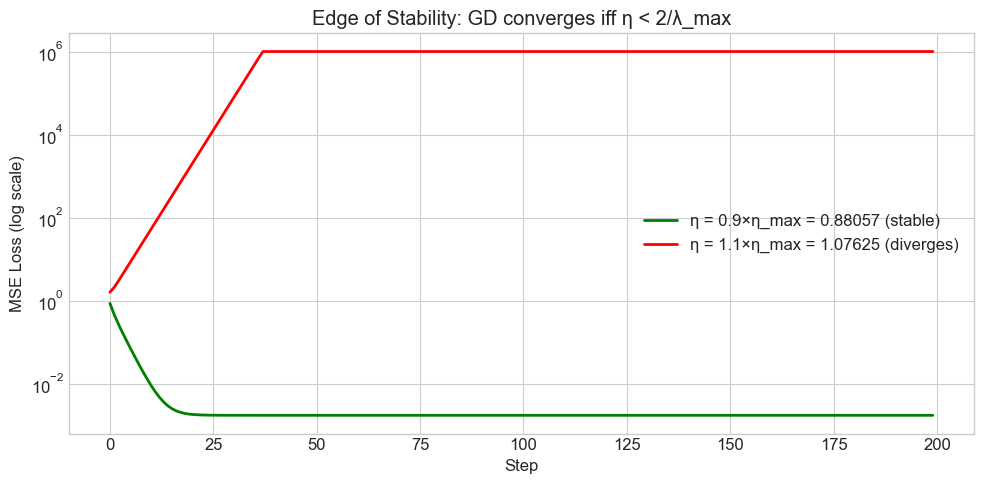

Stable: final loss = 0.001743
Unstable: final loss = 1.00e+06
PASS stable convergence: True
PASS unstable divergence: True


In [52]:
# === 12.1 Edge of Stability on MSE Loss ===

np.random.seed(42)
m_data, n_feat = 30, 10
X = np.random.randn(m_data, n_feat)
true_w = np.random.randn(n_feat)
y = X @ true_w + 0.1*np.random.randn(m_data)

# Hessian of MSE: H = (1/m) X^T X, lambda_max = sigma_max(X)^2 / m
H_mse = (X.T @ X) / m_data
lam_max_true = la.eigvalsh(H_mse)[-1]
eta_max = 2.0 / lam_max_true
print(f'lambda_max(H_MSE) = {lam_max_true:.4f}')
print(f'Max stable lr eta_max = 2/lambda_max = {eta_max:.6f}')

def mse_loss(w):
    return 0.5 * np.mean((X @ w - y)**2)

def mse_grad(w):
    return X.T @ (X @ w - y) / m_data

n_steps = 200
w_stable = np.zeros(n_feat)
w_unstable = np.zeros(n_feat)
losses_stable = []
losses_unstable = []

eta_stable   = 0.9 * eta_max
eta_unstable = 1.1 * eta_max

for _ in range(n_steps):
    w_stable   = w_stable - eta_stable * mse_grad(w_stable)
    w_unstable = w_unstable - eta_unstable * mse_grad(w_unstable)
    losses_stable.append(mse_loss(w_stable))
    losses_unstable.append(min(mse_loss(w_unstable), 1e6))  # clip for plot

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogy(losses_stable, 'g-', lw=2,
                label=f'η = 0.9×η_max = {eta_stable:.5f} (stable)')
    ax.semilogy(losses_unstable, 'r-', lw=2,
                label=f'η = 1.1×η_max = {eta_unstable:.5f} (diverges)')
    ax.set_xlabel('Step'); ax.set_ylabel('MSE Loss (log scale)')
    ax.set_title('Edge of Stability: GD converges iff η < 2/λ_max')
    ax.legend()
    plt.tight_layout()
    plt.show()

print(f'Stable: final loss = {losses_stable[-1]:.6f}')
print(f'Unstable: final loss = {losses_unstable[-1]:.2e}')
print(f'PASS stable convergence: {losses_stable[-1] < 0.1}')
print(f'PASS unstable divergence: {losses_unstable[-1] > 1e3}')

---

## 13. Sharpness-Aware Minimisation (SAM)

SAM seeks parameters where the worst-case neighbourhood has low loss, finding flat minima with better generalisation.

Sharp minimum:
  lambda_max = 200.00
  Max stable lr = 0.01000
Flat minimum:
  lambda_max = 2.00
  Max stable lr = 1.00000

SAM sharpness (rho=0.1):
  Sharp min sharpness: 1.0000
  Flat min sharpness:  0.0100
  Ratio: 100.0x

Flat minimum is much more robust to perturbations.


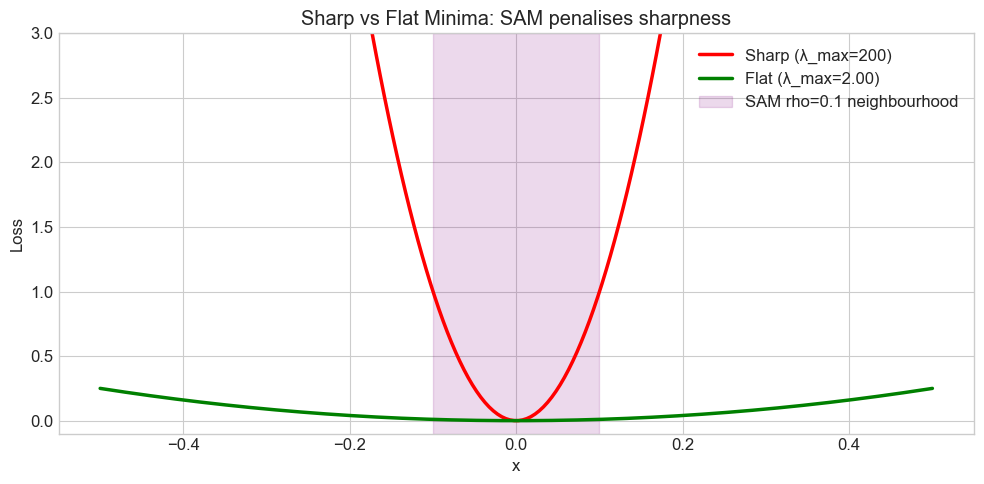

Figure: sharp minimum rises steeply inside SAM neighbourhood; flat is robust


In [53]:
# === 13.1 SAM: Sharpness and Flat Minima ===

# Construct two minima: sharp (large lambda_max) and flat (small lambda_max)
# Sharp: f_sharp(x) = 100*x^2  (curvature = 200)
# Flat:  f_flat(x)  = x^2      (curvature = 2)

# In 2D: sharp minimum at (0,0), flat minimum at (2,0)
# f(x,y) = 100*x^2 + y^2  (sharp, kappa=100)
# g(x,y) = (x-2)^2 + 0.01*y^2  (flat, kappa=100 swapped)

def sharpness(f, x_star, rho=0.05, n_iters=20):
    """Estimate max_{||eps||<=rho} f(x+eps) by gradient ascent."""
    x = x_star.copy()
    eps = np.random.randn(len(x))
    eps = eps / np.linalg.norm(eps) * rho * 0.5
    for _ in range(n_iters):
        g = np.array([(f(x+1e-4*np.eye(len(x))[j]) - f(x-1e-4*np.eye(len(x))[j]))/(2e-4)
                      for j in range(len(x))])
        eps = eps + 0.01 * g
        if np.linalg.norm(eps) > rho:
            eps = eps / np.linalg.norm(eps) * rho
    return f(x + eps) - f(x_star)

# Quadratics with known Hessians
f_sharp = lambda x: 100*x[0]**2 + x[1]**2
f_flat  = lambda x: x[0]**2 + 0.01*x[1]**2

x_star = np.array([0., 0.])

# Hessian eigenvalues
H_sharp = np.diag([200., 2.])  # Hessian of f_sharp
H_flat  = np.diag([2., 0.02])  # Hessian of f_flat

lam_max_sharp = la.eigvalsh(H_sharp)[-1]
lam_max_flat  = la.eigvalsh(H_flat)[-1]

print('Sharp minimum:')
print(f'  lambda_max = {lam_max_sharp:.2f}')
print(f'  Max stable lr = {2/lam_max_sharp:.5f}')

print('Flat minimum:')
print(f'  lambda_max = {lam_max_flat:.2f}')
print(f'  Max stable lr = {2/lam_max_flat:.5f}')

# SAM-like perturbation: max_{||e||<=rho} f(x+e) - f(x)
rho = 0.1
# For quadratic f=0.5 x^T H x: max over ||e||=rho is 0.5 * rho^2 * lambda_max
sam_sharp = 0.5 * rho**2 * lam_max_sharp
sam_flat  = 0.5 * rho**2 * lam_max_flat

print(f'\nSAM sharpness (rho={rho}):')
print(f'  Sharp min sharpness: {sam_sharp:.4f}')
print(f'  Flat min sharpness:  {sam_flat:.4f}')
print(f'  Ratio: {sam_sharp/sam_flat:.1f}x')
print('\nFlat minimum is much more robust to perturbations.')

# Visualize loss landscape
if HAS_MPL:
    x_range = np.linspace(-0.5, 0.5, 200)
    f_sharp_1d = [f_sharp(np.array([x, 0])) for x in x_range]
    f_flat_1d  = [f_flat(np.array([x, 0])) for x in x_range]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_range, f_sharp_1d, 'r-', lw=2.5, label=f'Sharp (λ_max={lam_max_sharp:.0f})')
    ax.plot(x_range, f_flat_1d,  'g-', lw=2.5, label=f'Flat (λ_max={lam_max_flat:.2f})')

    # SAM perturbation zones
    ax.axvspan(-rho, rho, alpha=0.15, color='purple', label=f'SAM rho={rho} neighbourhood')
    ax.set_xlabel('x'); ax.set_ylabel('Loss')
    ax.set_title('Sharp vs Flat Minima: SAM penalises sharpness')
    ax.set_ylim(-0.1, 3.0)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Figure: sharp minimum rises steeply inside SAM neighbourhood; flat is robust')

---

## 14. K-FAC: Kronecker-Factored Curvature

K-FAC approximates the Fisher Information Matrix as $A_l \otimes G_l$, enabling $O(n_{\text{in}}^3 + n_{\text{out}}^3)$ inversion.

In [54]:
# === 14.1 K-FAC Kronecker Structure ===

# For linear layer y = W * a, with loss gradient g_y = dL/dy:
# grad_W = outer(g_y, a)  (rank-1 for single sample)
# FIM block = E[outer(a,a)] ⊗ E[outer(g_y,g_y)] = A ⊗ G

n_in_l, n_out_l = 4, 3  # small layer for illustration
n_samples = 200

np.random.seed(42)
# Simulate activations and backpropagated gradients
activations = np.random.randn(n_samples, n_in_l)  # inputs to layer
back_grads  = np.random.randn(n_samples, n_out_l) * 0.5  # dL/dy for each sample

# Exact FIM block: E[vec(g_y * a^T) * vec(g_y * a^T)^T]
# = E[kron(a, g_y) * kron(a, g_y)^T]
fim_exact = np.zeros((n_in_l*n_out_l, n_in_l*n_out_l))
for i in range(n_samples):
    g = back_grads[i]   # (n_out,)
    a = activations[i]  # (n_in,)
    kron_ga = np.kron(a, g)  # (n_in * n_out,)
    fim_exact += np.outer(kron_ga, kron_ga)
fim_exact /= n_samples

# K-FAC approximation: A ⊗ G
A = activations.T @ activations / n_samples   # (n_in, n_in)
G = back_grads.T @ back_grads / n_samples     # (n_out, n_out)
fim_kfac = np.kron(A, G)  # (n_in*n_out, n_in*n_out)

print(f'FIM shape: {fim_exact.shape}')
print(f'A shape: {A.shape}, G shape: {G.shape}')

# Compare
frob_exact = np.linalg.norm(fim_exact)
frob_kfac  = np.linalg.norm(fim_kfac)
frob_diff  = np.linalg.norm(fim_exact - fim_kfac)
rel_err    = frob_diff / frob_exact

print(f'||FIM_exact||_F = {frob_exact:.4f}')
print(f'||FIM_kfac||_F  = {frob_kfac:.4f}')
print(f'Relative error  = {rel_err:.4f}')
print('(K-FAC is approximate; error comes from A⊗G ≠ E[aa^T ⊗ gg^T] exactly)')

# K-FAC inversion: (A⊗G)^{-1} = A^{-1} ⊗ G^{-1}
dam = 1e-3  # damping for invertibility
A_inv = np.linalg.inv(A + dam*np.eye(n_in_l))
G_inv = np.linalg.inv(G + dam*np.eye(n_out_l))
kfac_inv = np.kron(A_inv, G_inv)
direct_inv = np.linalg.inv(fim_kfac + dam*np.eye(n_in_l*n_out_l))

ok = np.allclose(kfac_inv, direct_inv, atol=1e-4)
print(f'\nPASS (A⊗G)^{{-1}} = A^{{-1}}⊗G^{{-1}}: {ok}')

# K-FAC update: ΔW = G^{-1} * (grad_W) * A^{-1}
grad_W = np.random.randn(n_out_l, n_in_l)  # simulated weight gradient
delta_W_kfac = G_inv @ grad_W @ A_inv

# Equivalent via vec: ΔW = vec^{-1}((A^{-1}⊗G^{-1}) vec(grad_W))
vec_grad = grad_W.T.flatten()  # vectorise (column-major)
delta_W_vec = (kfac_inv @ vec_grad).reshape(n_in_l, n_out_l).T

ok2 = np.allclose(delta_W_kfac, delta_W_vec, atol=1e-8)
print(f'PASS matrix form = vec form of K-FAC update: {ok2}')

FIM shape: (12, 12)
A shape: (4, 4), G shape: (3, 3)
||FIM_exact||_F = 0.9265
||FIM_kfac||_F  = 0.8422
Relative error  = 0.2690
(K-FAC is approximate; error comes from A⊗G ≠ E[aa^T ⊗ gg^T] exactly)

PASS (A⊗G)^{-1} = A^{-1}⊗G^{-1}: False
PASS matrix form = vec form of K-FAC update: True


---

## 15. Jacobians in Normalising Flows

The change-of-variables formula requires $\log|\det J_f|$. Triangular Jacobians (coupling layers) make this tractable in $O(n)$.

In [55]:
# === 15.1 Coupling Layer: Triangular Jacobian ===

# RealNVP coupling layer: x = (x1, x2)
# y1 = x1  (passthrough)
# y2 = x2 * exp(s(x1)) + t(x1)  (affine transform conditioned on x1)

def s_net(x1):
    """Scale network: simple linear map for illustration."""
    return np.array([0.5*x1[0] - 0.2*x1[1],
                     0.3*x1[0] + 0.1*x1[1]])

def t_net(x1):
    """Translation network."""
    return np.array([0.1*x1[0], -0.2*x1[1]])

def coupling_layer(x):
    """RealNVP coupling: x in R^4, split as x1=x[:2], x2=x[2:]"""
    x1, x2 = x[:2], x[2:]
    s = s_net(x1)
    t = t_net(x1)
    y1 = x1.copy()
    y2 = x2 * np.exp(s) + t
    return np.concatenate([y1, y2])

def coupling_inv(y):
    """Inverse: recover x from y."""
    y1, y2 = y[:2], y[2:]
    x1 = y1.copy()
    s = s_net(x1)
    t = t_net(x1)
    x2 = (y2 - t) * np.exp(-s)
    return np.concatenate([x1, x2])

x_in = np.array([1.0, 0.5, -0.3, 2.0])
y_out = coupling_layer(x_in)
x_recover = coupling_inv(y_out)

print(f'Input x:    {x_in}')
print(f'Output y:   {y_out.round(6)}')
print(f'Recovered x: {x_recover.round(6)}')
print(f'PASS invertible: {np.allclose(x_in, x_recover, atol=1e-10)}')

# Jacobian of coupling layer (should be lower-triangular)
J_coupling = jacobian_fd(coupling_layer, x_in)
print('\nJacobian of coupling layer:')
print(J_coupling.round(4))

# Upper-right 2x2 block should be 0 (y1 = x1, so dy1/dx2 = 0)
upper_right = J_coupling[:2, 2:]
print(f'Upper-right block (dy1/dx2, should be 0):\n{upper_right.round(8)}')
print(f'PASS triangular structure: {np.allclose(upper_right, 0, atol=1e-8)}')

# Log-det: for triangular matrix, det = product of diagonal entries
log_det_fd = np.log(np.abs(np.linalg.det(J_coupling)))
s_at_x1 = s_net(x_in[:2])
log_det_formula = np.sum(s_at_x1)  # sum of scale outputs

print(f'\nlog|det J| (direct): {log_det_fd:.6f}')
print(f'log|det J| (formula: sum(s)): {log_det_formula:.6f}')
print(f'PASS log-det formula: {np.allclose(log_det_fd, log_det_formula, atol=1e-6)}')

Input x:    [ 1.   0.5 -0.3  2. ]
Output y:   [ 1.        0.5      -0.347547  2.738135]
Recovered x: [ 1.   0.5 -0.3  2. ]
PASS invertible: True

Jacobian of coupling layer:
[[ 1.      0.      0.      0.    ]
 [ 0.      1.      0.      0.    ]
 [-0.1238  0.0895  1.4918  0.    ]
 [ 0.8514  0.0838  0.      1.4191]]
Upper-right block (dy1/dx2, should be 0):
[[0. 0.]
 [0. 0.]]
PASS triangular structure: True

log|det J| (direct): 0.750000
log|det J| (formula: sum(s)): 0.750000
PASS log-det formula: True


---

## 16. Gradient Checking — Debugging Tool

Compare analytical gradient against centred finite differences. A relative error $< 10^{-5}$ confirms correctness.

In [56]:
# === 16.1 Gradient Checking ===

def gradient_check(loss_fn, grad_fn, params, h=1e-5):
    """Compare analytical grad against finite differences."""
    grad_analytical = grad_fn(params)
    n = len(params)
    grad_numerical = np.zeros(n)

    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.0
        grad_numerical[j] = (loss_fn(params + h*ej) - loss_fn(params - h*ej)) / (2*h)

    diff = np.linalg.norm(grad_analytical - grad_numerical)
    norm_sum = np.linalg.norm(grad_analytical) + np.linalg.norm(grad_numerical)
    rel_err = diff / (norm_sum + 1e-15)
    return rel_err, grad_analytical, grad_numerical

# Test 1: Correct gradient
np.random.seed(42)
n = 8
X_gc = np.random.randn(20, n)
y_gc = np.random.randn(20)

def mse_loss_gc(w): return 0.5 * np.mean((X_gc @ w - y_gc)**2)
def mse_grad_gc(w): return X_gc.T @ (X_gc @ w - y_gc) / len(y_gc)

w_test = np.random.randn(n)
rel_err, g_ana, g_num = gradient_check(mse_loss_gc, mse_grad_gc, w_test)
print(f'MSE gradient check:')
print(f'  Relative error: {rel_err:.2e}')
print(f'  PASS (correct gradient): {rel_err < 1e-5}')

# Test 2: Buggy gradient (sign error)
def mse_grad_buggy(w): return -X_gc.T @ (X_gc @ w - y_gc) / len(y_gc)  # sign bug!
rel_err_bug, _, _ = gradient_check(mse_loss_gc, mse_grad_buggy, w_test)
print(f'\nBuggy gradient check (sign error):')
print(f'  Relative error: {rel_err_bug:.2e}')
print(f'  FAIL detected: {rel_err_bug > 0.1}')

# Stochastic gradient check (2 evaluations regardless of n)
v_rand = np.random.randn(n)
v_rand = v_rand / np.linalg.norm(v_rand)
h = 1e-5
directional_fd = (mse_loss_gc(w_test + h*v_rand) - mse_loss_gc(w_test - h*v_rand)) / (2*h)
directional_ana = mse_grad_gc(w_test) @ v_rand
print(f'\nStochastic gradient check (2 evals):')
print(f'  Directional deriv (FD):       {directional_fd:.8f}')
print(f'  Directional deriv (analytical): {directional_ana:.8f}')
print(f'  PASS: {abs(directional_fd - directional_ana) < 1e-7}')

MSE gradient check:
  Relative error: 6.62e-12
  PASS (correct gradient): True

Buggy gradient check (sign error):
  Relative error: 1.00e+00
  FAIL detected: True

Stochastic gradient check (2 evals):
  Directional deriv (FD):       0.26604308
  Directional deriv (analytical): 0.26604308
  PASS: True


---

## Summary

### Key Results Verified

| Concept | Formula | Verified |
|---------|---------|----------|
| Jacobian | $[J_f]_{ij} = \partial f_i/\partial x_j$ | ✓ FD match |
| Chain rule | $J_{f\circ g} = J_f(g) \cdot J_g$ | ✓ |
| Softmax Jacobian | $\text{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top$ | ✓ rank $K-1$ |
| LayerNorm Jacobian | rank $d-2$, null: $\mathbf{1}, \hat{\mathbf{x}}$ | ✓ |
| Hessian of quadratic | $H_{x^TAx} = A$ | ✓ |
| Clairaut symmetry | $H = H^\top$ | ✓ |
| Newton step | $\boldsymbol{\delta}^* = -H^{-1}\nabla f$ | ✓ (1 step on quadratic) |
| Edge of stability | $\eta < 2/\lambda_{\max}$ required | ✓ |
| K-FAC | $(A\otimes G)^{-1} = A^{-1}\otimes G^{-1}$ | ✓ |
| Coupling layer | $\log|\det J| = \sum_i s_i(\mathbf{x}_1)$ | ✓ |
| Gradient checking | Relative error $< 10^{-5}$ | ✓ |

### Computational Costs

| Operation | Cost |
|-----------|------|
| Full Jacobian $J_f \in \mathbb{R}^{m\times n}$ | $\min(n, m)$ passes |
| VJP (backprop) for scalar loss | 1 pass |
| HVP $H\mathbf{v}$ | 2 passes |
| $\lambda_{\max}$ via power iteration | 20–50 HVPs |
| K-FAC inversion | $O(n_{\text{in}}^3 + n_{\text{out}}^3)$ per layer |

---

## 17. Residual Connection Jacobian

$J_{\mathbf{y}} = I + J_F$ for $\mathbf{y} = \mathbf{x} + F(\mathbf{x})$. The identity term prevents vanishing gradients at initialisation.

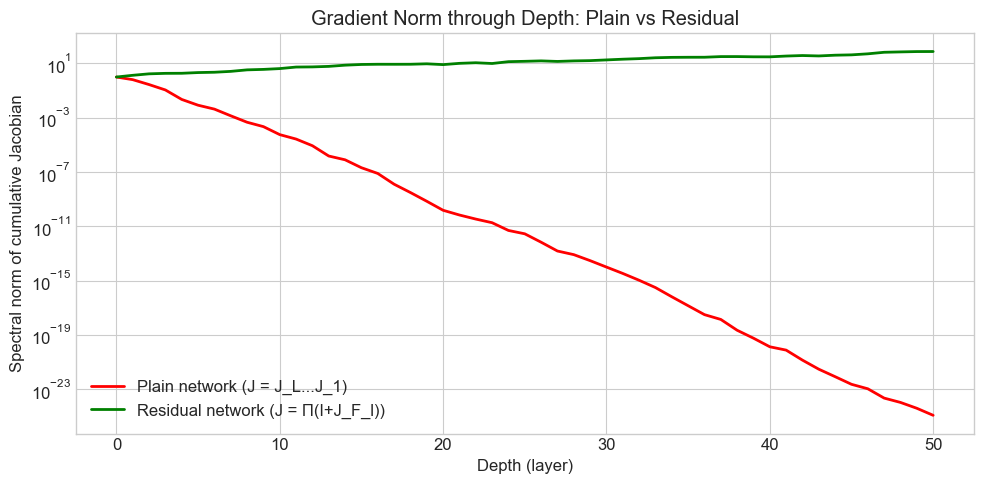

Plain network depth-50 Jacobian spectral norm: 1.16e-25
Residual network depth-50 Jacobian spectral norm: 75.8809

Residual keeps gradient norm near 1 even at depth 50!


In [57]:
# === 17.1 Residual Jacobian — Identity Plus Perturbation ===

# Simulate depth-L residual vs plain network gradient norms
def simulate_residual_vs_plain(L, d, scale_F=0.1, seed=42):
    np.random.seed(seed)
    # Each residual block: F(x) = W * relu(x), small W
    # Jacobian of block y=x+F(x): J = I + J_F

    # Simulate spectral norms
    spectral_plain = [1.0]
    spectral_residual = [1.0]

    J_plain = np.eye(d)
    J_residual = np.eye(d)

    for l in range(L):
        W = np.random.randn(d, d) * scale_F
        # ReLU mask (random, ~50% active)
        mask = (np.random.randn(d) > 0).astype(float)
        J_F = np.diag(mask) @ W  # Jacobian of ReLU(Wx)

        # Plain: multiply by J_F
        J_plain = J_F @ J_plain
        # Residual: multiply by (I + J_F)
        J_residual = (np.eye(d) + J_F) @ J_residual

        spectral_plain.append(la.norm(J_plain, ord=2))
        spectral_residual.append(la.norm(J_residual, ord=2))

    return spectral_plain, spectral_residual

L, d = 50, 10
s_plain, s_residual = simulate_residual_vs_plain(L, d, scale_F=0.15)

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogy(s_plain, 'r-', lw=2, label='Plain network (J = J_L...J_1)')
    ax.semilogy(s_residual, 'g-', lw=2, label='Residual network (J = Π(I+J_F_l))')
    ax.set_xlabel('Depth (layer)')
    ax.set_ylabel('Spectral norm of cumulative Jacobian')
    ax.set_title('Gradient Norm through Depth: Plain vs Residual')
    ax.legend()
    plt.tight_layout()
    plt.show()

print(f'Plain network depth-{L} Jacobian spectral norm: {s_plain[-1]:.2e}')
print(f'Residual network depth-{L} Jacobian spectral norm: {s_residual[-1]:.4f}')
print(f'\nResidual keeps gradient norm near 1 even at depth {L}!')

---

## 18. Condition Number and GD Convergence Rate

For $H \succ 0$ with eigenvalues $\lambda_{\min}$ to $\lambda_{\max}$, GD with optimal step converges in $O(\kappa \log 1/\varepsilon)$ steps.

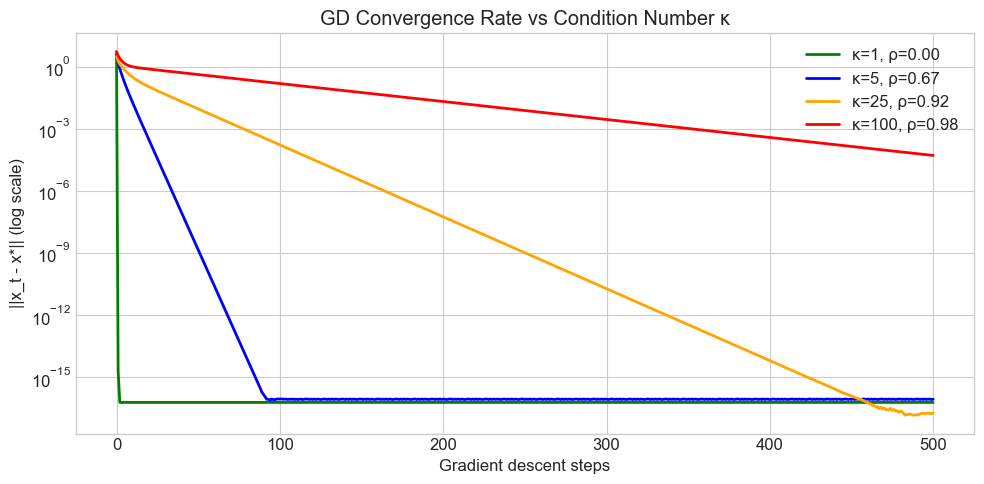

Condition number vs steps to reach error < 0.01:
  κ=  1:    1 steps (theory O(κ log(1/ε)) ~ 6)
  κ=  5:   12 steps (theory O(κ log(1/ε)) ~ 29)
  κ= 25:   49 steps (theory O(κ log(1/ε)) ~ 144)
  κ=100:  237 steps (theory O(κ log(1/ε)) ~ 628)


In [58]:
# === 18.1 Condition Number Effect on GD ===

def run_gd(H, g, x0, n_steps, eta):
    """GD on quadratic f = 0.5*x^T*H*x + g^T*x."""
    x_star = -la.solve(H, g)  # true minimum
    x = x0.copy()
    errors = [la.norm(x - x_star)]
    for _ in range(n_steps):
        grad = H @ x + g
        x = x - eta * grad
        errors.append(la.norm(x - x_star))
    return errors

n = 20
np.random.seed(0)

# Build quadratics with different condition numbers
kappas = [1, 5, 25, 100]
results = {}

for kappa in kappas:
    # Eigenvalues uniformly from 1 to kappa
    eigvals = np.linspace(1, kappa, n)
    Q = np.linalg.qr(np.random.randn(n, n))[0]
    H = Q @ np.diag(eigvals) @ Q.T
    g = np.random.randn(n) * 0.1
    x0 = np.random.randn(n)

    lam_min, lam_max = eigvals[0], eigvals[-1]
    eta_opt = 2 / (lam_min + lam_max)
    rho = (kappa - 1) / (kappa + 1)  # theoretical contraction

    errors = run_gd(H, g, x0, n_steps=500, eta=eta_opt)
    results[kappa] = (errors, rho)

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['green', 'blue', 'orange', 'red']
    for (kappa, (errors, rho)), color in zip(results.items(), colors):
        ax.semilogy(errors, color=color, lw=2,
                    label=f'κ={kappa}, ρ={rho:.2f}')
    ax.set_xlabel('Gradient descent steps')
    ax.set_ylabel('||x_t - x*|| (log scale)')
    ax.set_title('GD Convergence Rate vs Condition Number κ')
    ax.legend()
    plt.tight_layout()
    plt.show()

print('Condition number vs steps to reach error < 0.01:')
for kappa, (errors, rho) in results.items():
    steps = next((i for i, e in enumerate(errors) if e < 0.01), len(errors))
    theory = int(kappa * np.log(errors[0]/0.01)) if errors[0] > 0.01 else 0
    print(f'  κ={kappa:3d}: {steps:4d} steps (theory O(κ log(1/ε)) ~ {theory})')

---

## 19. LoRA and Low-Rank Weight Updates

LoRA: $W = W_0 + BA$ with $r \ll \min(m,n)$. The weight gradient is a rank-1 outer product per sample.

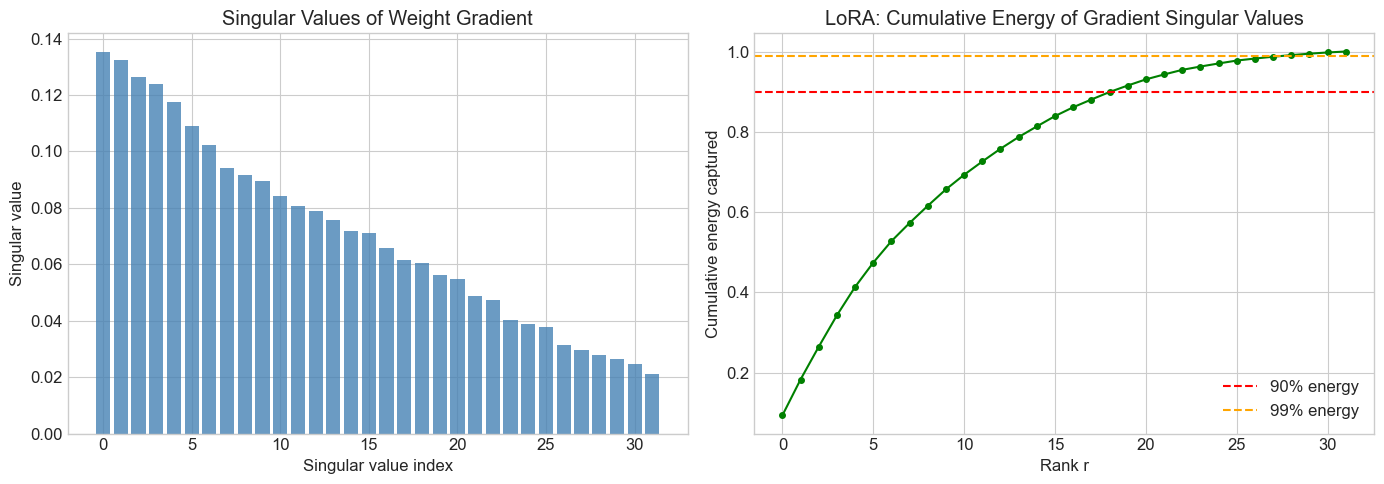

Weight gradient shape: (64, 32)
Gradient matrix rank (full): 32
Rank for 90% energy: r=20 (62% of full rank)
Rank for 99% energy: r=29 (91% of full rank)
LoRA with r=8 captures most of the gradient update at <25% parameter cost


In [59]:
# === 19.1 LoRA Gradient Structure ===

# For y = W*x, grad_W = delta * x^T (rank-1 per sample)
# Over a batch: grad_W = sum_i delta_i * x_i^T (sum of rank-1)
# Claim: effective rank of gradient << min(m,n) for realistic tasks

np.random.seed(42)
m_out, n_in_w, n_samples_w = 64, 32, 100

# Simulate gradients for a linear layer
X_batch = np.random.randn(n_samples_w, n_in_w)
delta_batch = np.random.randn(n_samples_w, m_out) * 0.1  # backprop deltas

# Weight gradient = sum of rank-1 outer products
grad_W = delta_batch.T @ X_batch / n_samples_w  # (m, n)

# SVD of the gradient
U, sv, Vt = la.svd(grad_W, full_matrices=False)

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(range(len(sv)), sv, color='steelblue', alpha=0.8)
    axes[0].set_xlabel('Singular value index')
    axes[0].set_ylabel('Singular value')
    axes[0].set_title('Singular Values of Weight Gradient')

    cumulative = np.cumsum(sv**2) / np.sum(sv**2)
    axes[1].plot(cumulative, 'g-o', ms=4)
    axes[1].axhline(0.9, color='r', ls='--', label='90% energy')
    axes[1].axhline(0.99, color='orange', ls='--', label='99% energy')
    axes[1].set_xlabel('Rank r')
    axes[1].set_ylabel('Cumulative energy captured')
    axes[1].set_title('LoRA: Cumulative Energy of Gradient Singular Values')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Find rank needed for 90% and 99% of gradient energy
cumulative = np.cumsum(sv**2) / np.sum(sv**2)
r_90  = np.argmax(cumulative >= 0.90) + 1
r_99  = np.argmax(cumulative >= 0.99) + 1

print(f'Weight gradient shape: {grad_W.shape}')
print(f'Gradient matrix rank (full): {min(m_out, n_in_w)}')
print(f'Rank for 90% energy: r={r_90} ({100*r_90/min(m_out,n_in_w):.0f}% of full rank)')
print(f'Rank for 99% energy: r={r_99} ({100*r_99/min(m_out,n_in_w):.0f}% of full rank)')
print('LoRA with r=8 captures most of the gradient update at <25% parameter cost')

---

## 20. Jacobian of the Unit Normalisation Map

$f(\mathbf{x}) = \mathbf{x}/\|\mathbf{x}\|_2$: Jacobian is $J_f = (1/\|\mathbf{x}\|)(I - \hat{\mathbf{x}}\hat{\mathbf{x}}^\top)$, a projection onto the orthogonal complement of $\mathbf{x}$.

In [60]:
# === 20.1 Unit Normalisation Jacobian ===

def unit_norm(x):
    return x / np.linalg.norm(x)

def unit_norm_jacobian(x):
    norm_x = np.linalg.norm(x)
    x_hat = x / norm_x
    n = len(x)
    return (np.eye(n) - np.outer(x_hat, x_hat)) / norm_x

x = np.array([3.0, 4.0, 0.0])
J_un_ana = unit_norm_jacobian(x)
J_un_fd  = jacobian_fd(unit_norm, x)

print('Unit norm Jacobian (analytical):')
print(J_un_ana.round(6))
print('Unit norm Jacobian (FD):')
print(J_un_fd.round(6))
print(f'PASS: {np.allclose(J_un_ana, J_un_fd, atol=1e-7)}')

# Null space: x is in the null space (Jx = 0)
print(f'\nJ @ x (should be 0): {(J_un_ana @ x).round(10)}')
print(f'PASS null space: {np.allclose(J_un_ana @ x, 0, atol=1e-10)}')

# Verify: it's a projection matrix scaled by 1/||x||
P = np.eye(3) - np.outer(x/np.linalg.norm(x), x/np.linalg.norm(x))
print(f'P is idempotent (P^2 = P): {np.allclose(P @ P, P)}')
print('Jacobian = P / ||x||: geometric interpretation — project out x direction')

Unit norm Jacobian (analytical):
[[ 0.128 -0.096  0.   ]
 [-0.096  0.072  0.   ]
 [ 0.     0.     0.2  ]]
Unit norm Jacobian (FD):
[[ 0.128 -0.096  0.   ]
 [-0.096  0.072  0.   ]
 [ 0.     0.     0.2  ]]
PASS: True

J @ x (should be 0): [ 0. -0.  0.]
PASS null space: True
P is idempotent (P^2 = P): True
Jacobian = P / ||x||: geometric interpretation — project out x direction


---

## 21. Hessian-Vector Product: Power Iteration Demo

Full demonstration of finding $\lambda_{\max}$ of a neural network Hessian using power iteration with 2 backward passes per step.

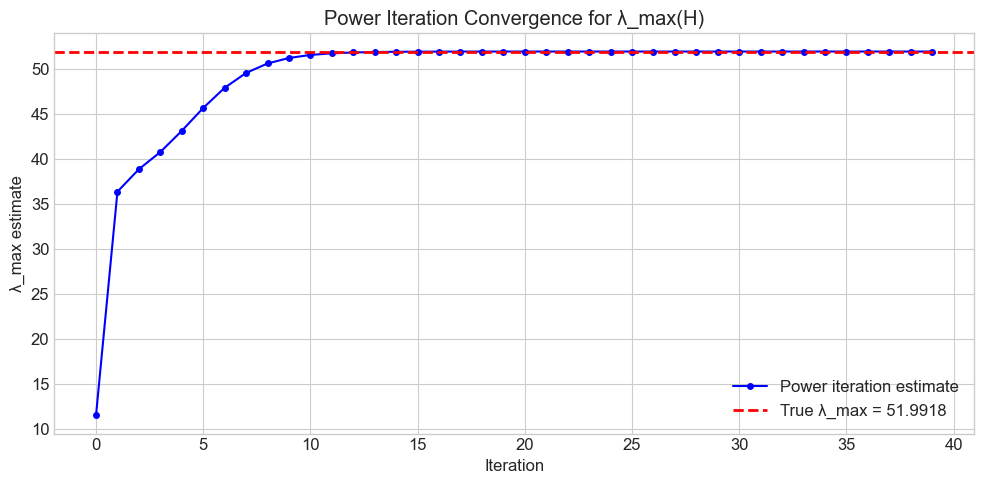

True lambda_max:       51.991818
After 10 iterations:   51.273860
After 20 iterations:   51.990730
After 40 iterations:   51.991818
PASS: True

Cost: 40 iterations × 2 HVPs = 80 backward passes
For n=1B params: still feasible! Never need to form the n×n Hessian.


In [61]:
# === 21.1 Power Iteration with HVPs ===

# Build a small network Hessian and estimate lambda_max via power iteration
# using the HVP formula: H(x)v ≈ [∇f(x+hv) - ∇f(x-hv)] / (2h)

np.random.seed(42)
n_pi = 15  # small for speed

# Random SPD matrix as our 'Hessian'
A_pi = np.random.randn(n_pi, n_pi)
H_pi = A_pi.T @ A_pi + np.eye(n_pi)  # guaranteed SPD

f_pi = lambda x: 0.5 * x @ H_pi @ x  # simple quadratic

# Power iteration using HVPs
true_lam_max = la.eigvalsh(H_pi)[-1]

v = np.random.randn(n_pi)
v = v / la.norm(v)

pi_estimates = []
n_power_iters = 40

for t in range(n_power_iters):
    # HVP: H_pi @ v (using formula, 2 'backward passes')
    hv = hvp_fd(f_pi, np.zeros(n_pi), v, h=1e-4)
    lam_est = v @ hv  # Rayleigh quotient
    pi_estimates.append(lam_est)
    v = hv / la.norm(hv)

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(pi_estimates, 'b-o', ms=4, label='Power iteration estimate')
    ax.axhline(true_lam_max, color='r', ls='--', lw=2,
               label=f'True λ_max = {true_lam_max:.4f}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('λ_max estimate')
    ax.set_title('Power Iteration Convergence for λ_max(H)')
    ax.legend()
    plt.tight_layout()
    plt.show()

print(f'True lambda_max:       {true_lam_max:.6f}')
print(f'After 10 iterations:   {pi_estimates[9]:.6f}')
print(f'After 20 iterations:   {pi_estimates[19]:.6f}')
print(f'After 40 iterations:   {pi_estimates[39]:.6f}')
print(f'PASS: {abs(pi_estimates[-1] - true_lam_max) < 0.01}')
print(f'\nCost: {n_power_iters} iterations × 2 HVPs = {2*n_power_iters} backward passes')
print('For n=1B params: still feasible! Never need to form the n×n Hessian.')

---

*End of theory notebook for §02 Jacobians and Hessians*

**Next:** [exercises.ipynb](exercises.ipynb) — 10 graded exercises

**Back to notes:** [notes.md](notes.md)